In [41]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments, scale_filter
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn_1d, strfn, statfunc_base
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from scipy.signal import windows

import itertools

import h5py

D = 1

N = 10000
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]
twopi = 2.*np.pi
dk = twopi/L
dx = L/N
BREAK = 100 * dk


In [42]:

f0 = h5py.File('T.Fr.h5', 'r')
field = f0['T.Fr'][:]


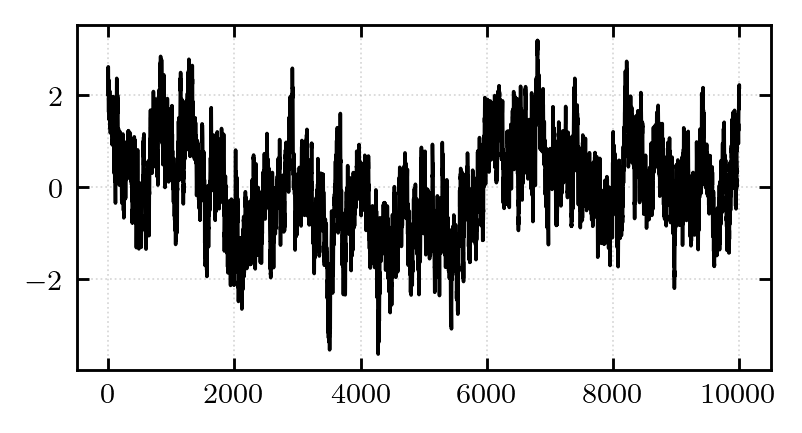

In [43]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

ax.plot(field, linewidth=1., color='black')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')


In [44]:

l, sf = strfn_1d.process_lags(field, N//2, periodic=False)
l = l * dx


In [45]:

lv_p = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
sf_p = strfn.process_lags(field, field, lv_p, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=False)[0]
lvm_p = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx
l_p, sf2_p, w_p = statistics_base.bin_data(lvm_p, sf_p, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dx, max_bin=L/2., num_bins=N//3, bin_loc='true_center')


/home/m/anaconda3/envs/Kea/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


Text(0, 0.5, 'SF')

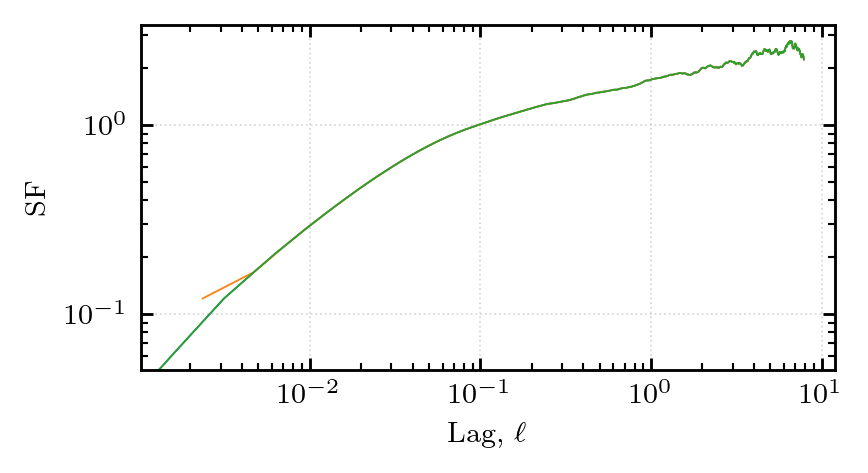

In [47]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

ax.plot(l, sf, linewidth=0.5)
ax.plot(l_p, sf2_p, linewidth=0.5)

l_mpi = np.load('l.npy')
sf_mpi = np.load('sf.npy')

ax.plot(l_mpi*dx, sf_mpi, linewidth=0.5)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlabel(r'Lag, $\ell$')
ax.set_ylabel(r'SF')
